In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ecommerce_sales_data1.csv")

df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,31-12-2024,Printer,Office,North,4,3640,348.93
1,27-11-2022,Mouse,Accessories,East,7,1197,106.53
2,11-05-2022,Tablet,Electronics,South,5,5865,502.73
3,16-03-2024,Mouse,Accessories,South,2,786,202.87
4,10-09-2022,Mouse,Accessories,West,1,509,103.28


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


In [4]:
df.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

In [5]:
df = df.dropna()

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop_duplicates()

In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

C:\Users\USER2024\AppData\Local\Temp\ipykernel_16020\13081262.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order Date"] = pd.to_datetime(df["Order Date"])


In [9]:
df["Month"] = df["Order Date"].dt.month

In [10]:
df["Year"] = df["Order Date"].dt.year

In [11]:
total_sales = df["Sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 10667881


In [12]:
total_profit = df["Profit"].sum()
print("Total Profit:", total_profit)

Total Profit: 1844665.21


In [13]:
sales_category = df.groupby("Category")["Sales"].sum()
print(sales_category)

Category
Accessories    4247591
Electronics    5326074
Office         1094216
Name: Sales, dtype: int64


In [14]:
sales_region = df.groupby("Region")["Sales"].sum()
print(sales_region)

Region
East     2675110
North    2488773
South    2659548
West     2844450
Name: Sales, dtype: int64


In [15]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_products)

Product Name
Camera        1177381
Monitor       1160048
Printer       1094216
Mouse         1074398
Smartphone    1069681
Smartwatch    1049211
Keyboard      1024507
Tablet        1023928
Laptop        1005873
Headphones     988638
Name: Sales, dtype: int64


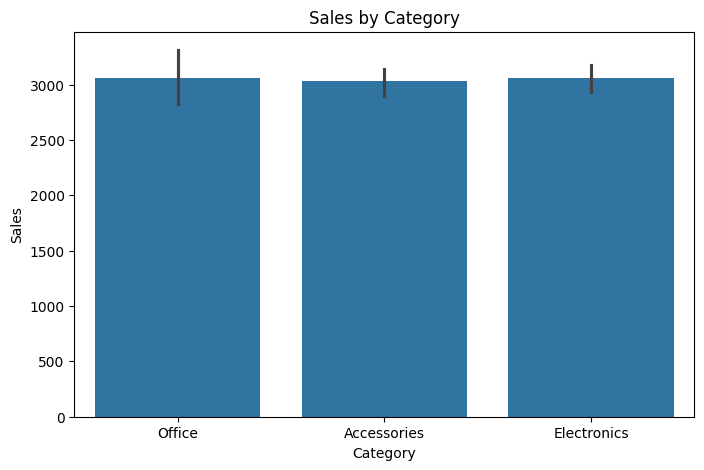

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(x="Category", y="Sales", data=df)
plt.title("Sales by Category")
plt.show()

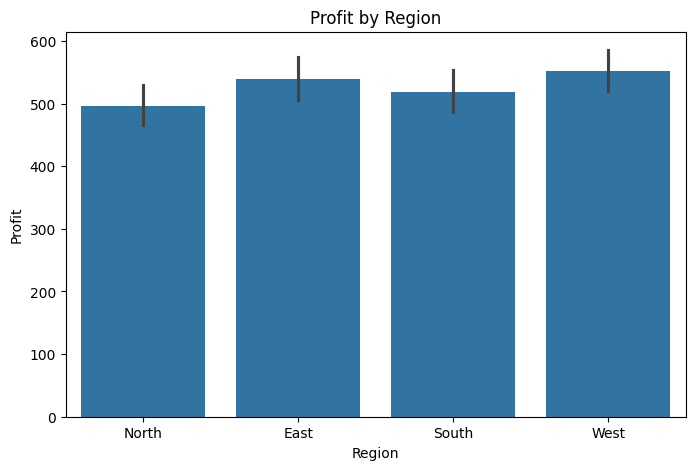

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(x="Region", y="Profit", data=df)
plt.title("Profit by Region")
plt.show()

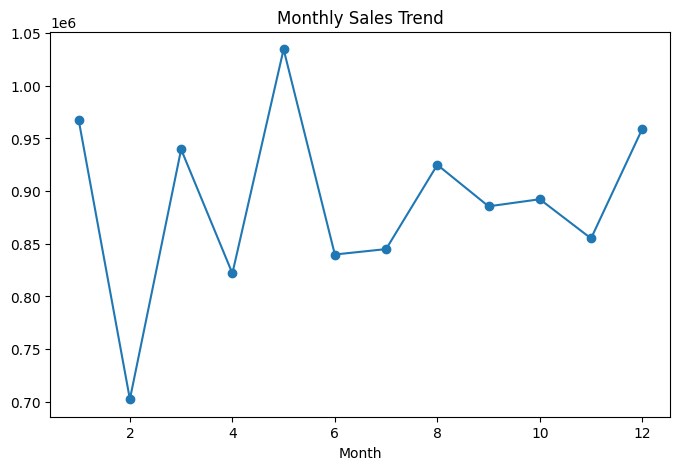

In [18]:
monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.show()

In [19]:
df.to_csv("clean_ecommerce_sales.csv", index=False)